# Loan Default Prediction and Profit-Aware Model Selection

## Business Context

Credit-risk models are useful only when predictive performance translates into better lending decisions. A lender needs to identify applicants with elevated default risk while avoiding overly conservative rules that reject too many profitable customers.

This notebook treats loan default as a binary classification problem and compares several models using both statistical performance and a simplified business-profit function. That makes the model-selection process closer to the decision the business actually needs to make.

## Objective

The objective is to estimate default risk, compare alternative classification approaches, and select a decision threshold that balances predictive quality with the financial cost assigned to correct and incorrect lending decisions.

The workflow starts with an interpretable FICO-only logistic model, then expands to multivariable logistic regression, decision trees with pruning, and XGBoost.

### Step 1: Import Required Libraries

Load the packages used for exploratory analysis, statistical modeling, tree-based models, gradient boosting, visualization, and model evaluation.

In [1]:
!pip install skimpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.6/120.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 52.2 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter_client 7.4.9
    Uninstalling jupyter_client-7.4.9:
      Successfully uninstalled jupyter_client-7.4.9
  Attempting uninstall: ipykernel
    Found existing installation: ipykernel 6.17.1
    Uninstalling ipykernel-6.17.1:
      Successfully uninstalled ipykernel-6.17.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipykernel==6.17.1, but you have ipykernel 7.3.0 which is incompatible.
notebook 6.5.7 requires jupyter-client<8,>=5.3.4, but you ha

In [1]:
### Import necessary libraries
import warnings
import xgboost
import numpy as np
import seaborn as sns
import pandas as pd
import codecs
import statsmodels.api as sm
import sklearn as skl
import skimpy as skim
import matplotlib.pyplot as plt
from datetime import datetime
from statsmodels.formula.api import ols
from statsmodels.formula.api import logit
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from pandas.errors import SettingWithCopyWarning
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

### Step 2: Load, Clean, and Explore the Data

Load the loan dataset, remove records missing the target or FICO score, and enforce the expected target type. The descriptive statistics provide the first view of class balance, borrower profiles, and the scale of the available predictors.

In [2]:
df = pd.read_csv("/data/loans.csv")
print(df.head())

   default  installment  log_income  fico_score  rev_balance  inquiries  \
0        0          829        4.93         737        28.85          0   
1        0          228        4.81         707        33.62          0   
2        0          367        4.51         682         3.51          1   
3        0          162        4.93         712        33.67          1   
4        0          103        4.91         667         4.74          0   

   records  
0        0  
1        0  
2        0  
3        0  
4        0  


In [3]:
# Clean missing values and ensure correct data type
df = df.dropna(subset=['default', 'fico_score']).copy()
df['default'] = df['default'].astype(int)
df.describe()

,default,installment,log_income,fico_score,rev_balance,inquiries,records
count,9516.000000,9516.000000,9516.000000,9516.000000,9516.000000,9516.000000,9516.000000
mean,0.159836,320.142077,4.748656,710.841950,16.988948,1.572930,0.062211
std,0.366473,207.066550,0.265017,37.956246,33.721352,2.200329,0.262406
min,0.000000,16.000000,3.280000,612.000000,0.000000,0.000000,0.000000
25%,0.000000,164.000000,4.590000,682.000000,3.270000,0.000000,0.000000
50%,0.000000,269.500000,4.750000,707.000000,8.690000,1.000000,0.000000
75%,0.000000,435.250000,4.900000,737.000000,18.355000,2.000000,0.000000
max,1.000000,940.000000,6.310000,827.000000,1207.360000,33.000000,5.000000


To understand how borrower profiles differ by outcome, split the data into defaulted and non-defaulted loans. This comparison is useful for spotting directional patterns before fitting a predictive model.

In [4]:
default_df = df[df.default == 1]
print(default_df.head())

    default  installment  log_income  fico_score  rev_balance  inquiries  \
6         1          194        4.65         667         3.84          0   
7         1          131        4.78         722        24.22          0   
57        1          678        5.16         682        41.67          0   
65        1           33        4.53         687         4.49          1   
73        1          225        5.33         677        56.41          0   

    records  
6         1  
7         0  
57        0  
65        0  
73        0  


In [5]:
no_default_df = df[df.default == 0]
print(no_default_df.head())

   default  installment  log_income  fico_score  rev_balance  inquiries  \
0        0          829        4.93         737        28.85          0   
1        0          228        4.81         707        33.62          0   
2        0          367        4.51         682         3.51          1   
3        0          162        4.93         712        33.67          1   
4        0          103        4.91         667         4.74          0   

   records  
0        0  
1        0  
2        0  
3        0  
4        0  


Compare the descriptive statistics of the two outcome groups. The purpose is not to infer causality, but to identify variables that may contain useful risk signal and to understand the characteristics of each class.

In [6]:
no_default_df.describe()

,default,installment,log_income,fico_score,rev_balance,inquiries,records
count,7995.0,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000,7995.000000
mean,0.0,315.542464,4.752088,713.307067,16.181555,1.428143,0.056535
std,0.0,203.361193,0.260654,38.209948,29.542831,1.997417,0.255646
min,0.0,16.000000,3.280000,612.000000,0.000000,0.000000,0.000000
25%,0.0,163.000000,4.600000,682.000000,3.250000,0.000000,0.000000
50%,0.0,268.000000,4.750000,707.000000,8.630000,1.000000,0.000000
75%,0.0,425.500000,4.910000,742.000000,18.000000,2.000000,0.000000
max,0.0,940.000000,6.310000,827.000000,952.010000,31.000000,5.000000


In [7]:
default_df.describe()

,default,installment,log_income,fico_score,rev_balance,inquiries,records
count,1521.0,1521.000000,1521.000000,1521.000000,1521.000000,1521.000000,1521.000000
mean,1.0,344.319527,4.730618,697.884287,21.232939,2.333991,0.092045
std,0.0,224.068429,0.286276,33.764233,50.066968,2.938440,0.293699
min,1.0,16.000000,3.300000,617.000000,0.000000,0.000000,0.000000
25%,1.0,169.000000,4.560000,672.000000,3.400000,0.000000,0.000000
50%,1.0,290.000000,4.730000,692.000000,8.940000,1.000000,0.000000
75%,1.0,492.000000,4.900000,717.000000,20.700000,3.000000,0.000000
max,1.0,927.000000,5.850000,822.000000,1207.360000,33.000000,2.000000


The exploratory comparison shows several practical differences between the groups. Non-defaulted loans have a higher average FICO score, while defaulted loans show a lower credit score and somewhat larger installment amounts. Income differs only slightly between the two groups.

These patterns suggest that creditworthiness is not captured by one variable alone. FICO score is informative, but repayment risk is likely to depend on a combination of credit history, debt burden, income, inquiries, and derogatory records. That observation motivates the multivariable models later in the notebook.

### Step 3: Build an Interpretable Baseline

Split the data into training and test sets and start with a logistic regression that uses only FICO score. This model is intentionally simple: it establishes how much predictive value can be obtained from a single familiar credit-risk variable before adding more features.

In [8]:
df_train,df_test = train_test_split(df,test_size = 0.3,random_state=42,stratify=df['default'])

In [9]:
df_train.describe()

,default,installment,log_income,fico_score,rev_balance,inquiries,records
count,6661.000000,6661.000000,6661.000000,6661.000000,6661.000000,6661.000000,6661.000000
mean,0.159886,322.408497,4.750161,710.726918,17.150354,1.585197,0.063354
std,0.366528,207.900592,0.265933,37.831725,35.747063,2.221479,0.262600
min,0.000000,16.000000,3.280000,612.000000,0.000000,0.000000,0.000000
25%,0.000000,165.000000,4.580000,682.000000,3.310000,0.000000,0.000000
50%,0.000000,273.000000,4.750000,707.000000,8.770000,1.000000,0.000000
75%,0.000000,441.000000,4.910000,737.000000,18.380000,2.000000,0.000000
max,1.000000,940.000000,6.160000,822.000000,1207.360000,33.000000,5.000000


The training sample remains close to the full dataset distribution, with defaults representing roughly 16% of observations. FICO score and installment statistics are also consistent with the overall sample.

This matters because the first model will be evaluated on a held-out set; a representative split reduces the risk that the comparison is driven by a materially different class mix.

In [10]:
est = logit(formula = 'default ~ fico_score',data = df_train).fit()

print(est.summary())

Optimization terminated successfully.
         Current function value: 0.426576
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 6661
Model:                          Logit   Df Residuals:                     6659
Method:                           MLE   Df Model:                            1
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                 0.02936
Time:                        00:24:31   Log-Likelihood:                -2841.4
converged:                       True   LL-Null:                       -2927.4
Covariance Type:            nonrobust   LLR p-value:                 2.824e-39
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.1187      0.697     10.208      0.000       5.752       8.486
fico_score    -0.0125      0.

### Step 4: Generate Predictions and Evaluate the Baseline

Use the fitted logistic model to estimate a probability of default for each observation in the test set. The probabilities are then converted into decisions using a 25% cutoff so the resulting confusion matrix can be inspected.

In [11]:
preds = est.predict(df_test)
df_test['predicted_probability'] = preds
# print top 5 predicted probabilities
df_test.head()


,default,installment,log_income,fico_score,rev_balance,inquiries,records,predicted_probability
9206,0,80,5.00,702,34.07,4,0,0.164836
5000,0,479,4.43,737,0.05,0,0,0.113196
2845,0,700,4.78,742,24.03,3,0,0.107095
1205,0,262,4.71,697,5.33,2,0,0.173586
3163,0,307,4.81,747,10.11,6,0,0.101285


Create a binary `will_default` decision using a 25% probability threshold. This threshold is lower than the conventional 50% cutoff because the business may prefer to flag more risky loans when the cost of an undetected default is high.

In [12]:
df_test['will_default'] = None
df_test = df_test.sort_values(by='default').reset_index(drop=True)
df_test['predicted_probability'] = df_test['predicted_probability'].fillna(0)
df_test['will_default'] = np.where(df_test['predicted_probability']>0.25,1,0).astype(int)

print(df_test)

      default  installment  log_income  fico_score  rev_balance  inquiries  \
0           0          330        4.64         732        14.87          0   
1           0          307        4.93         677         0.04          2   
2           0          333        4.95         737        61.37          2   
3           0          360        4.65         757        12.34          0   
4           0           39        3.60         682         0.90          1   
...       ...          ...         ...         ...          ...        ...   
2850        1          659        5.28         757        26.33          1   
2851        1          200        5.21         762       141.17          1   
2852        1          597        4.88         697        38.54          3   
2853        1          235        4.78         722         0.26          0   
2854        1          248        4.50         652         8.38          1   

      records  predicted_probability  will_default  
0         

Build a confusion matrix to separate true negatives, false positives, false negatives, and true positives. For a credit-risk use case, this view is more informative than accuracy alone because false negatives correspond to borrowers predicted as safe who actually defaulted.

In [13]:
matrix = confusion_matrix(df_test['default'], df_test['will_default'])
print(matrix)

[[2298  101]
 [ 419   37]]


<Axes: >

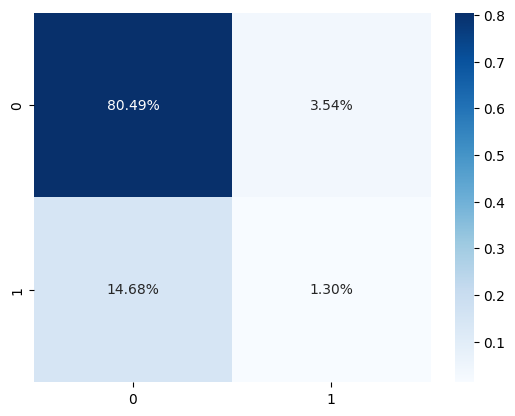

In [14]:
sns.heatmap(matrix/np.sum(matrix), annot=True,
            fmt='.2%', cmap='Blues')

<Axes: >

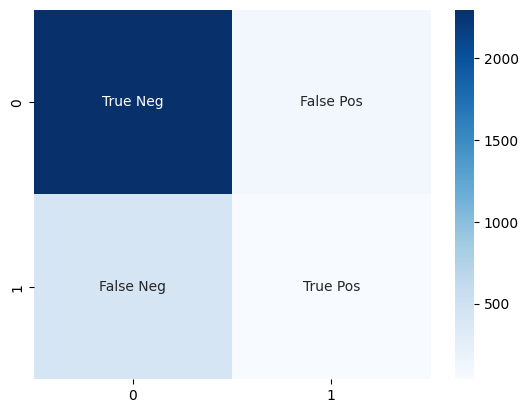

In [15]:
labels = ["True Neg","False Pos","False Neg","True Pos"]
labels = np.asarray(labels).reshape(2,2)
sns.heatmap(matrix, annot=labels, fmt="", cmap='Blues')

Calculate the main classification rates for the baseline model. These metrics provide a clearer view of the trade-off created by the selected threshold.

In [16]:
total = len(df_test)
true_pos = matrix[1,1]
false_pos = matrix[0,1]
false_neg = matrix[1,0]
true_neg = matrix[0,0]

acc_rate = (true_pos + true_neg) / total # the probability the model correctly categorizes a data point
error_rate = (false_pos + false_neg) / total # the probability the model incorrectly categorizes a data point

true_pos_rate = true_pos / (true_pos + false_neg) # the probability the model correctly categorizes a data point given it's positive
false_pos_rate = false_pos / (true_neg + false_pos) # the probability the model incorrectly categorizes a negative result as a positive one

true_neg_rate = true_neg / (true_neg + false_pos) # the probability the model correctly categorizes a data point given it's negative
false_neg_rate = false_neg / (true_pos + false_neg) # the probability the model incorrectly categorizes a positive result as a negative one

print(f'Accuracy:{100.0*acc_rate:.3f}%', f'Error:{100.0*error_rate:.3f}%')
print(f'True positive rate:{100.0*true_pos_rate:.3f}%', f'False positive rate:{100.0*false_pos_rate:.3f}%')
print(f'True negative rate:{100.0*true_neg_rate:.3f}%', f'False negative rate:{100.0*false_neg_rate:.3f}%')

Accuracy:81.786% Error:18.214%
True positive rate:8.114% False positive rate:4.210%
True negative rate:95.790% False negative rate:91.886%


The FICO-only model reaches approximately **81.8% accuracy**, but the confusion matrix shows that it detects only a small share of actual defaults at the chosen cutoff. The false-negative rate is therefore a material concern.

From a business perspective, this is exactly why overall accuracy is not enough for imbalanced credit-risk problems. A model can classify the majority class well and still miss many of the events that carry the highest financial cost.

### Step 5: Define Profit-Aware Evaluation Functions

Create helper functions that translate model predictions into a simplified financial outcome.

The notebook assigns a profit of **\$1,000** to a true negative and a loss of **\$5,000** to a false negative. The functions then:

- Calculate profit at a selected probability cutoff.
- Compare profit across multiple cutoffs.
- Identify the cutoff with the highest observed profit.
- Visualize a fitted decision tree.

This moves model selection away from a purely statistical metric and toward the economics of the lending decision.

In [17]:
def profit(y, y_pred, cutoff=0.5, verbose=False):
  '''
  Given a probability cutoff, predicted probabilities, and actual y values,
  calculates the profit per applicant
  '''
  will_default = np.where(y_pred >= cutoff, 1, 0)
  cm = confusion_matrix(y, will_default)
  if verbose:
    ConfusionMatrixDisplay.from_predictions(
        y,
        will_default,
        display_labels = ['No Default', 'Default']
        )
  cm_profit = 1000*cm[0,0]-5000*cm[1,0]
  return cm_profit/len(y)

def profit_table(y, y_pred, cutoffs=np.arange(0,1.01,0.1)):
  '''
  Given predicted probabilities, actual y values, and a set of cutoffs,
  calculates the profit per applicant for each cutoff
  and returns it in a two-column dataframe
  '''
  return pd.DataFrame({'cutoff': cutoffs,
                       'profit': [profit(y, y_pred, cutoff) for cutoff in cutoffs]})

def best_profit_and_cutoff(y, y_pred):
  '''
  Given predicted probabilities and actual y values, returns the optimal
  cutoff and optimal profit per applicant
  '''
  pf = profit_table(y, y_pred)
  idx = pf.profit.idxmax()
  return pf.loc[idx]

def viz_tree(tree, font=12, figsize=(16,10)):
  '''
  draws a classification tree
  '''
  plt.figure(figsize=figsize)  # set plot size (denoted in inches)
  _ = plot_tree(tree,
                feature_names=X.columns,
                filled=True,
                fontsize=font)

### Step 6: Recreate the Train-Test Split for Model Comparison

Prepare the full feature set for the next group of models. The target is separated from the predictors so logistic regression, tree-based models, and XGBoost can be compared using the same profit-oriented logic.

In [18]:
df_train, df_test = train_test_split(df, test_size=0.3, random_state=42)
X = df_train.copy()
y = X.pop('default')
X_test = df_test.copy()
y_test = X_test.pop('default')

### Step 7: Fit Multivariable Logistic Regression

Fit a logistic regression using installment amount, income, FICO score, revolving balance, inquiries, and derogatory records. The model remains interpretable while allowing default probability to depend on several borrower characteristics at the same time.

The stored profit table reaches its best displayed value at a **0.20 cutoff**, with an estimated profit per applicant of **$153.41** under the notebook's simplified payoff assumptions.

In [19]:
formula="default ~ installment + log_income + fico_score + rev_balance + inquiries + records"
est = logit(formula=formula, data=df_train).fit()
print(est.summary())

Optimization terminated successfully.
         Current function value: 0.415078
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 6661
Model:                          Logit   Df Residuals:                     6654
Method:                           MLE   Df Model:                            6
Date:                Sun, 13 Sep 2026   Pseudo R-squ.:                 0.05338
Time:                        00:24:31   Log-Likelihood:                -2764.8
converged:                       True   LL-Null:                       -2920.7
Covariance Type:            nonrobust   LLR p-value:                 2.415e-64
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       9.7634      0.994      9.824      0.000       7.816      11.711
installment     0.0013    

In [20]:
y_pred = est.predict(X_test)
pf_table = profit_table(y_test, y_pred)
bestpf = best_profit_and_cutoff(y_test, y_pred)
print(pf_table)
print(f'Cutoff for best profit:{bestpf['cutoff']}')
print(f'Best profit:{bestpf['profit']}')

    cutoff      profit
0      0.0    0.000000
1      0.1  152.014011
2      0.2  153.415061
3      0.3  113.835377
4      0.4   57.793345
5      0.5   42.732049
6      0.6   32.574431
7      0.7   32.924694
8      0.8   32.924694
9      0.9   33.274956
10     1.0   33.274956
Cutoff for best profit:0.2
Best profit:153.41506129597198


### Step 8: Fit a Decision Tree with Default Parameters

Train an unconstrained decision tree as a non-linear alternative to logistic regression. The goal is to see whether recursive feature splits can capture interactions and risk thresholds that a linear log-odds model may miss.

In [21]:
tree = DecisionTreeClassifier(random_state=42)

In [22]:
tree.fit(X,y)

DecisionTreeClassifier(random_state=42)

In [23]:
y_pred = tree.predict_proba(X_test)[:,1]
profit_table(y_test, y_pred)

,cutoff,profit
0,0.0,0.000000
1,0.1,74.255692
2,0.2,74.255692
3,0.3,74.255692
4,0.4,74.255692
5,0.5,74.255692
6,0.6,74.255692
7,0.7,74.255692
8,0.8,74.255692
9,0.9,74.255692


The default tree produces a lower profit than the multivariable logistic model. Before drawing a conclusion from that result, inspect the tree complexity because a very deep tree can memorize the training data and generalize poorly.

In [24]:
tree.tree_.max_depth, tree.tree_.node_count

(35, 2515)

The fitted tree has **35 levels and 2,515 nodes**, which is a strong indication that the default configuration is too complex for this dataset. Cost-complexity pruning is therefore used to trade a small amount of training fit for better out-of-sample behavior and interpretability.

### Step 9: Prune the Decision Tree

Use the cost-complexity parameter `ccp_alpha` to generate trees with different levels of pruning. Each candidate tree is evaluated out of sample, and the model with the best test profit is selected.

This approach is useful because it links tree complexity directly to the business metric rather than choosing a tree size based only on training performance.

In [25]:
tree = DecisionTreeClassifier(random_state=42)

In [26]:
path = tree.cost_complexity_pruning_path(X,y)

In [27]:
alphas = path.ccp_alphas
print(f"The process will generate {len(alphas)} trees.")

The process will generate 436 trees.


In [28]:
trees = []
for alpha in alphas:
  tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
  tree.fit(X,y)
  trees.append(tree)

Search the candidate trees for the configuration that produces the highest profit on the test set.

In [29]:
def all_trees_profits_cutoffs(X,y):
  max_profit = []
  best_cutoff = []
  for tree in trees:
    y_pred = tree.predict_proba(X)[:,1]
    pf = best_profit_and_cutoff(y, y_pred)
    max_profit.append(pf['profit'])
    best_cutoff.append(pf['cutoff'])
  return max_profit, best_cutoff

In [30]:
train_profits, train_cutoffs = all_trees_profits_cutoffs(X,y)
test_profits, test_cutoffs = all_trees_profits_cutoffs(X_test,y_test)

Plot profit against tree size to make the bias-variance trade-off easier to see and to identify whether additional complexity continues to create business value.

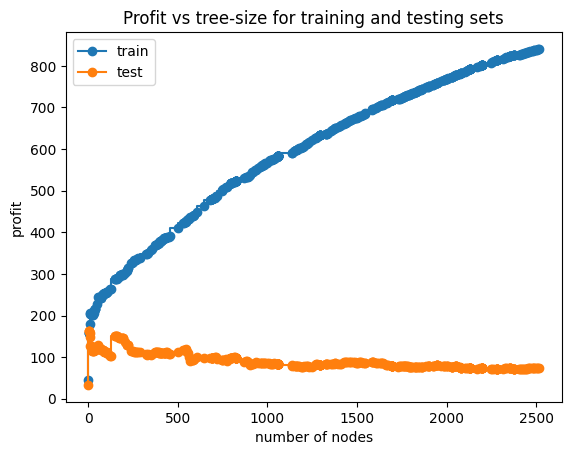

In [31]:
node_counts = [tree.tree_.node_count for tree in trees]
depth = [tree.tree_.max_depth for tree in trees]

fig, ax = plt.subplots()
ax.set_xlabel("number of nodes")
ax.set_ylabel("profit")
ax.set_title("Profit vs tree-size for training and testing sets")
ax.plot(node_counts, train_profits, marker="o", label="train", drawstyle="steps-post")
ax.plot(node_counts, test_profits, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

Zoom in on the most relevant region of the curve to inspect the best-performing compact trees more closely.

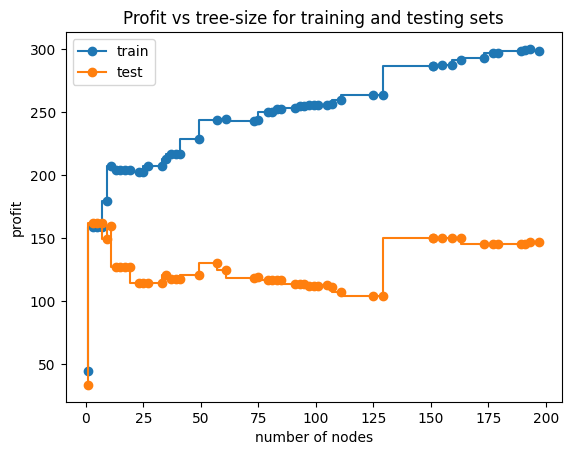

In [32]:
fig, ax = plt.subplots()
ax.set_xlabel("number of nodes")
ax.set_ylabel("profit")
ax.set_title("Profit vs tree-size for training and testing sets")
ax.plot(node_counts[-50:], train_profits[-50:], marker="o", label="train", drawstyle="steps-post")
ax.plot(node_counts[-50:], test_profits[-50:], marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show()

In [33]:
opt_idx = np.argmax(test_profits)

print(f"Profit of max-profit tree = ${max(test_profits):.2f}")
print(f"Size of max-profit tree = {node_counts[opt_idx]} nodes")
print(f"Optimal cutoff for chosen tree = {test_cutoffs[opt_idx]:.2f}")

Profit of max-profit tree = $161.82
Size of max-profit tree = 7 nodes
Optimal cutoff for chosen tree = 0.20


The selected pruned tree improves substantially over the original tree. The stored output shows a maximum test profit per applicant of **\$161.82** with only **7 nodes** and a **0.20 cutoff**.

This is an important result: the smaller tree is both more interpretable and more profitable under the notebook's assumptions. Pruning is not only a regularization technique here; it materially improves the decision outcome.

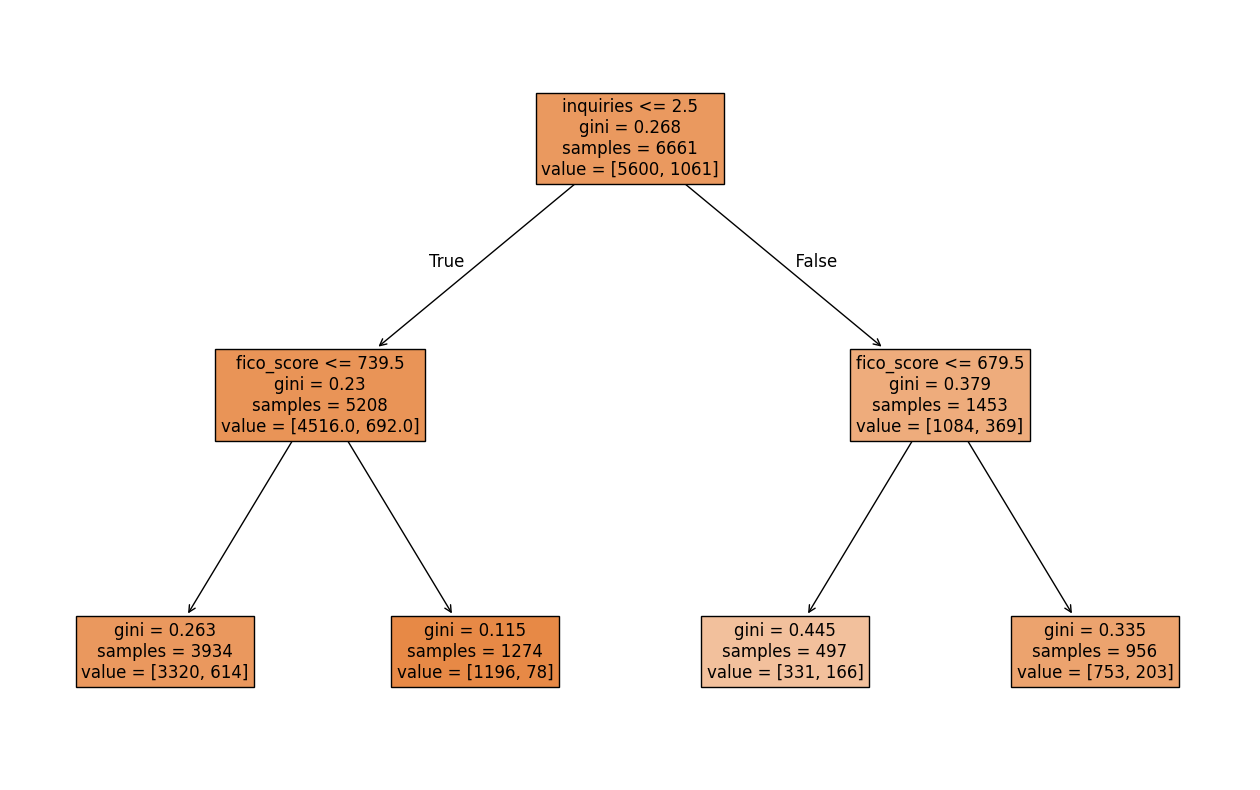

In [34]:
tree = trees[opt_idx]
viz_tree(tree)

---

### Step 10: Train an XGBoost Classifier

Train a gradient-boosted tree model as a higher-capacity alternative. Boosting can capture non-linear relationships and interactions while reducing some of the instability associated with a single decision tree.

The trade-off is interpretability: the model can be powerful, but its individual predictions are harder to explain directly than those from logistic regression or a small tree.

In [35]:
X = df.drop(['default'], axis=1)
y = df['default']

# Encode string class values as integers to avoid errors in newer versions of XGBoost
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
label_encoder = label_encoder.fit(y)
y = label_encoder.transform(y)

# Splitting data into training and test set:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
eval_set=[(X_test, y_test)]
print(X_train.shape, X_test.shape)

(6661, 6) (2855, 6)


In [36]:
print('Initializing xgboost.sklearn.XGBClassifier and starting training...')

st = datetime.now()

clf = xgboost.sklearn.XGBClassifier(
    objective="binary:logistic",
    learning_rate=0.05,
    seed=9616,
    max_depth=20,
    gamma=10,
    n_estimators=500,
    early_stopping_rounds=20,
    eval_metric="auc",
    )

clf.fit(X_train, y_train,
        eval_set=eval_set,
        verbose=False)
print(datetime.now()-st)

Initializing xgboost.sklearn.XGBClassifier and starting training...
0:00:00.404266


### Step 11: Evaluate XGBoost

Evaluate the fitted model using accuracy, ROC-AUC, the same profit table, and feature importance. Using a common business metric allows the model to be compared with the earlier approaches on the decision objective rather than on accuracy alone.

In [37]:
### predict give the number of correct classifications when cutoff is 0.5
### Using this information, I can find the accuracy of the model
accuracy = accuracy_score(y_test,clf.predict(X_test))
print("Accuracy: %.10f%%" % (accuracy * 100.0))

### predict_proba give the probabilities for the prediction to be 0 or 1
### Using this information, I can find the best cutoff and the best profit possible
accuracy_per_roc_auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:,1])
print("ROC-AUC: %.10f%%" % (accuracy_per_roc_auc * 100))

pf_table = profit_table(y_test, clf.predict_proba(X_test)[:,1])
bestpf = best_profit_and_cutoff(y_test, clf.predict_proba(X_test)[:,1])
print(pf_table)
print(f'Cutoff for best profit:{bestpf['cutoff']}')
print(f'Best profit:{bestpf['profit']}')

Accuracy: 83.8879159370%
ROC-AUC: 64.2947717164%
    cutoff      profit
0      0.0    0.000000
1      0.1  114.886165
2      0.2  145.359019
3      0.3   60.245184
4      0.4   33.274956
5      0.5   33.274956
6      0.6   33.274956
7      0.7   33.274956
8      0.8   33.274956
9      0.9   33.274956
10     1.0   33.274956
Cutoff for best profit:0.2
Best profit:145.35901926444834


The stored XGBoost results show approximately **83.9% accuracy**, **64.3% ROC-AUC**, and a best displayed profit per applicant of **\$145.35** at a **0.20 cutoff**.

Feature importance provides an additional diagnostic for understanding which variables drive the boosted model, although importance scores should not be interpreted as causal effects.

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

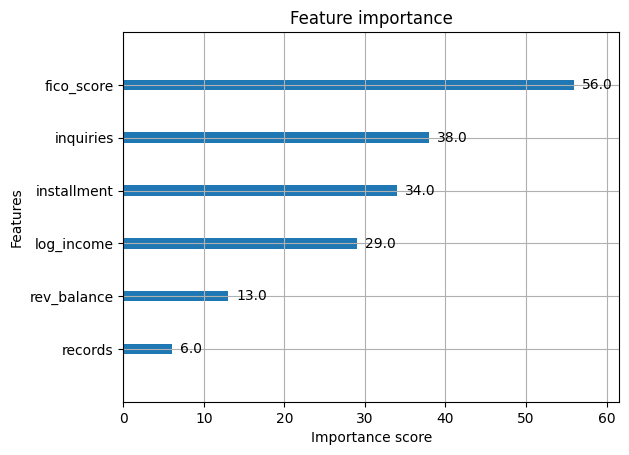

In [38]:
xgboost.plot_importance(clf)

## Conclusions

### Technical Takeaways

The notebook shows why model evaluation must match the problem. The FICO-only logistic model provides a transparent baseline, but its confusion matrix reveals that accuracy alone hides a weak ability to identify defaults.

Using the stored outputs and the notebook's payoff assumptions:

- Multivariable logistic regression reaches a best displayed profit per applicant of **\$153.41**.
- The unpruned decision tree is highly complex and underperforms.
- The selected pruned tree reaches the highest displayed test profit per applicant at **\$161.82**, with only **7 nodes**.
- XGBoost reaches approximately **83.9% accuracy**, **64.3% ROC-AUC**, and a best displayed profit per applicant of **\$145.35**.

For this specific experiment, the pruned tree gives the strongest balance of business value and interpretability. The result also highlights that the most complex model is not automatically the best model.

### Business Takeaways

Threshold selection has a direct financial effect. A conventional 0.50 cutoff is not necessarily appropriate when the cost of lending to a future defaulter is much larger than the opportunity cost of rejecting a safe borrower.

The simplified profit function makes this trade-off visible, but a production lending model would require more realistic economics: expected interest income, exposure at default, recovery rates, acquisition cost, approval rates, and regulatory constraints should all be incorporated before deployment.

Credit decisions also require strong governance. Model explainability, fairness testing, monitoring for population drift, and documented adverse-action logic are essential considerations beyond raw predictive performance.

### Next Steps

A production-oriented extension would validate the models with cross-validation or an out-of-time test set, calibrate predicted probabilities, evaluate recall/precision and PR-AUC, test fairness across relevant groups, and replace the simplified payoff matrix with a finance-approved expected-value model.

The code in this notebook provides the full comparison framework and makes it straightforward to test those additions without changing the core business question.